# Họ và Tên: Trần Lê Hồng Sơn
# MSSV: 207CT65800

### Câu 1 (2 điểm): Cho một ảnh bất kỳ (tên ảnh do sinh viên tự đặt, ví dụ: `my_image.jpg`) và thực hiện các yêu cầu sau:

* Viết chương trình sử dụng median filter để làm mịn ảnh. (0.5 điểm)  
* Viết chương trình sử dụng Sobel filter để xác định biên của hình ảnh. (0.5 điểm)  
* Đổi màu ảnh bằng cách hoán đổi thứ tự các kênh màu (ví dụ: BGR → GRB hoặc GBR...) và lưu thành tên dạng `[ten_anh]_swapped.jpg`. (0.5 điểm)  
* Chuyển ảnh sang không gian màu LAB và tách riêng 3 kênh L, A, B, lưu thành ảnh grayscale tương ứng (`[ten_anh]_L.jpg`, `[ten_anh]_A.jpg`, `[ten_anh]_B.jpg`). (0.5 điểm)


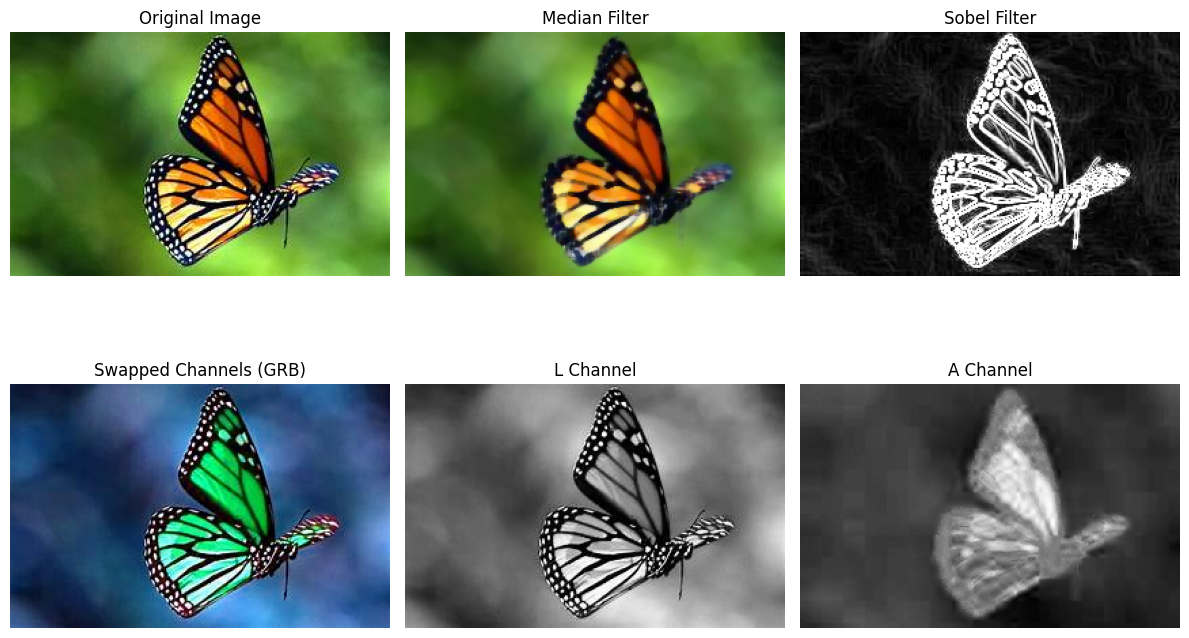

True

In [3]:
import cv2
import matplotlib.pyplot as plt


image = cv2.imread('my_image.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  

# 1. Median filter
median = cv2.medianBlur(image, 5)

# 2. Sobel filter
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)
sobel = cv2.convertScaleAbs(sobel)

swapped = image[:, :, [1, 2, 0]]
swapped_rgb = cv2.cvtColor(swapped, cv2.COLOR_BGR2RGB)  

lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
L, A, B = cv2.split(lab)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(cv2.cvtColor(median, cv2.COLOR_BGR2RGB))
plt.title('Median Filter')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(sobel, cmap='gray')
plt.title('Sobel Filter')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(swapped_rgb)
plt.title('Swapped Channels (GRB)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(L, cmap='gray')
plt.title('L Channel')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(A, cmap='gray')
plt.title('A Channel')
plt.axis('off')

plt.tight_layout()
plt.show()

# Lưu file như yêu cầu
cv2.imwrite('my_image_median.jpg', median)
cv2.imwrite('my_image_sobel.jpg', sobel)
cv2.imwrite('my_image_swapped.jpg', swapped)
cv2.imwrite('my_image_L.jpg', L)
cv2.imwrite('my_image_A.jpg', A)
cv2.imwrite('my_image_B.jpg', B)



### Câu 2 (4 điểm) Viết một chương trình Python sử dụng OpenCV để tạo menu tương tác cho phép người dùng chọn các kỹ thuật lọc và xử lý ảnh nâng cao từ một danh sách, áp dụng đồng thời cho nhiều ảnh.

### Yêu cầu:

1. Menu gồm:  
* Gaussian Blur (kernel size ngẫu nhiên lẻ từ 3 đến 11) (0.5 điểm)  
* Median Blur (kernel size ngẫu nhiên lẻ từ 3 đến 11) (0.5 điểm)  
* Bilateral Filter (tham số ngẫu nhiên) (0.5 điểm)  
* Canny Edge Detection (thresholds ngẫu nhiên 50–150) (0.5 điểm)  
* Erosion (kernel 2x2 đến 5x5 ngẫu nhiên) (0.5 điểm)  
* Dilation (tương tự Erosion) (0.5 điểm)

2. Chương trình xử lý đồng thời 3 ảnh bất kỳ do sinh viên tự chọn (có thể chọn bằng đường dẫn file hoặc nhập tên ảnh tùy ý). (0.5 điểm)

3. Phím tương ứng để kích hoạt các phương pháp xử lý:  
* B: Gaussian Blur  
* M: Median Blur  
* F: Bilateral Filter  
* E: Canny Edge  
* R: Erosion  
* D: Dilation (0.5 điểm)

4. Lưu file kết quả với định dạng: `result_[phương pháp]_[tên ảnh gốc].jpg`  
   Ví dụ: `result_blur_dog.jpg`, `result_canny_image2.jpg` (0.5 điểm)



Chọn phím xử lý:
B: Gaussian Blur
M: Median Blur
F: Bilateral Filter
E: Canny Edge
R: Erosion
D: Dilation



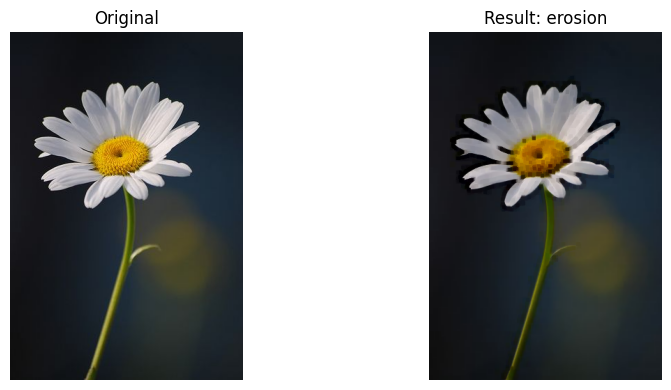

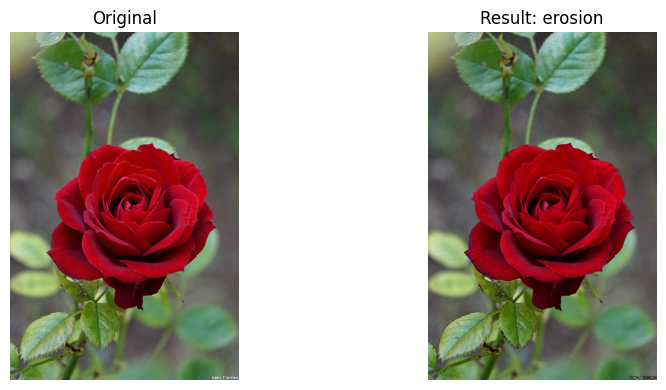

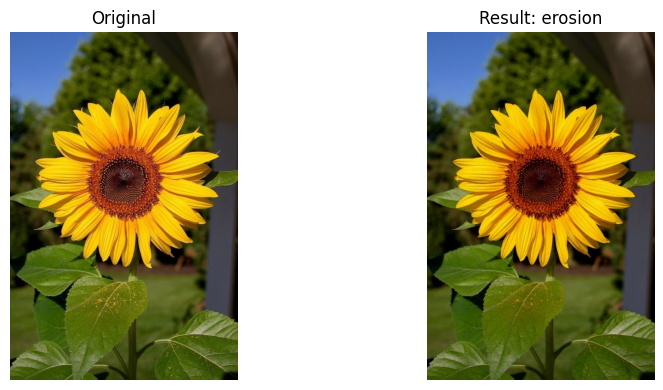

In [6]:
import cv2
import os
import random
import matplotlib.pyplot as plt

image_dir = "exam"

image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))]

# Menu lựa chọn
print("""
Chọn phím xử lý:
B: Gaussian Blur
M: Median Blur
F: Bilateral Filter
E: Canny Edge
R: Erosion
D: Dilation
""")

choice = input("Nhập phím xử lý (B/M/F/E/R/D): ").upper()

for img_name in image_files:
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)

    result = None
    method = ""

    if choice == "B":
        k = random.choice([3, 5, 7, 9, 11])
        result = cv2.GaussianBlur(img, (k, k), 0)
        method = "blur"
    elif choice == "M":
        k = random.choice([3, 5, 7, 9, 11])
        result = cv2.medianBlur(img, k)
        method = "median"
    elif choice == "F":
        d = random.randint(5, 15)
        sigma_color = random.randint(50, 150)
        sigma_space = random.randint(50, 150)
        result = cv2.bilateralFilter(img, d, sigma_color, sigma_space)
        method = "bilateral"
    elif choice == "E":
        t1 = random.randint(50, 100)
        t2 = random.randint(100, 150)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        result = cv2.Canny(gray, t1, t2)
        method = "canny"
    elif choice == "R":
        k = random.choice([2, 3, 5])
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
        result = cv2.erode(img, kernel, iterations=1)
        method = "erosion"
    elif choice == "D":
        k = random.choice([2, 3, 5])
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
        result = cv2.dilate(img, kernel, iterations=1)
        method = "dilation"
    else:
        print("Lựa chọn không hợp lệ!")
        exit()


    base_name = os.path.splitext(img_name)[0]
    out_name = f"result_{method}_{base_name}.jpg"

    
    cv2.imwrite(out_name, result)
   
    plt.figure(figsize=(10, 4))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    if method == "canny":
        plt.imshow(result, cmap='gray')
    else:
        result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
        plt.imshow(result_rgb)
    plt.title(f'Result: {method}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


### Câu 3 (4 điểm) Viết một chương trình Python để xử lý 3 ảnh bất kỳ do sinh viên tự chọn.

* Tăng kích thước ảnh đầu tiên thêm 35 pixel ở mỗi cạnh. (0.5 điểm)  
* Xoay ảnh thứ hai 135 độ và lật ngang. (0.5 điểm)  
* Tăng kích thước ảnh thứ ba lên 5 lần và làm mịn bằng Gaussian blur kernel 9x9. (1.5 điểm)  
* Thay đổi độ sáng và độ tương phản ảnh thứ ba bằng công thức:

$$
I_{out}(x, y) = \alpha \cdot I_{in}(x, y) + \beta
$$

Trong đó:  

$$
\alpha \in [0.5, 2.0], \quad \beta \in [-50, 50]
$$

Giá trị đầu ra cần được giới hạn trong khoảng [0, 255] bằng công thức:

$$
I_{out}(x, y) = \text{clip}(I_{out}(x, y), 0, 255)
$$


Alpha: 0.96, Beta: 9


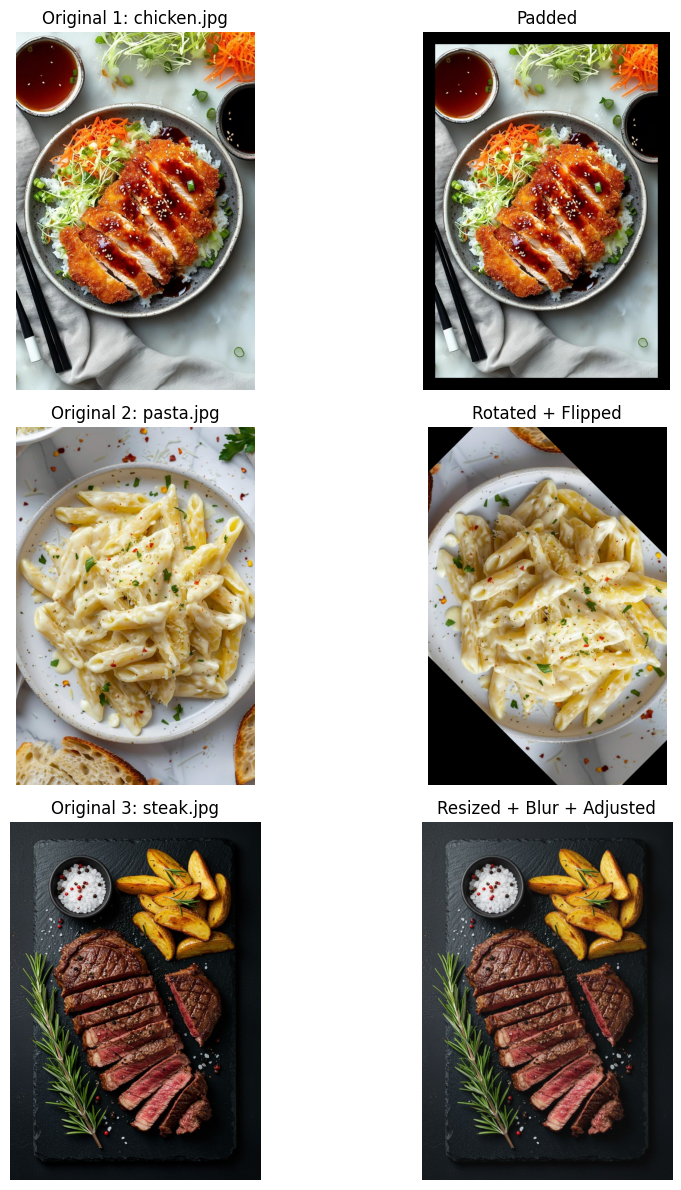

In [ ]:
import cv2
import os
import numpy as np
import random
import matplotlib.pyplot as plt

# Thư mục chứa ảnh
image_dir = "exam1"
image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))]

img1 = cv2.imread(os.path.join(image_dir, image_files[0]))
h, w = img1.shape[:2]
top, bottom, left, right = [35]*4
img1_padded = cv2.copyMakeBorder(img1, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0])
cv2.imwrite(f"result_padding_{image_files[0]}", img1_padded)

img2 = cv2.imread(os.path.join(image_dir, image_files[1]))
(h2, w2) = img2.shape[:2]
center = (w2 // 2, h2 // 2)
M = cv2.getRotationMatrix2D(center, 135, 1.0)
rotated = cv2.warpAffine(img2, M, (w2, h2))
flipped = cv2.flip(rotated, 1)
cv2.imwrite(f"result_rotate_flip_{image_files[1]}", flipped)

img3 = cv2.imread(os.path.join(image_dir, image_files[2]))
img3_resized = cv2.resize(img3, None, fx=5, fy=5, interpolation=cv2.INTER_LINEAR)
img3_blur = cv2.GaussianBlur(img3_resized, (9, 9), 0)

alpha = random.uniform(0.5, 2.0)
beta = random.randint(-50, 50)

adjusted = cv2.convertScaleAbs(img3_blur, alpha=alpha, beta=beta)
cv2.imwrite(f"result_resize_blur_adjust_{image_files[2]}", adjusted)

print(f"Alpha: {alpha:.2f}, Beta: {beta}")

fig, axs = plt.subplots(3, 2, figsize=(10, 12))

# Ảnh 1
axs[0, 0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axs[0, 0].set_title(f'Original 1: {image_files[0]}')
axs[0, 0].axis('off')

axs[0, 1].imshow(cv2.cvtColor(img1_padded, cv2.COLOR_BGR2RGB))
axs[0, 1].set_title('Padded')
axs[0, 1].axis('off')

# Ảnh 2
axs[1, 0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axs[1, 0].set_title(f'Original 2: {image_files[1]}')
axs[1, 0].axis('off')

axs[1, 1].imshow(cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB))
axs[1, 1].set_title('Rotated + Flipped')
axs[1, 1].axis('off')

# Ảnh 3
axs[2, 0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
axs[2, 0].set_title(f'Original 3: {image_files[2]}')
axs[2, 0].axis('off')

axs[2, 1].imshow(cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB))
axs[2, 1].set_title('Resized + Blur + Adjusted')
axs[2, 1].axis('off')

plt.tight_layout()
plt.show()


# Chúc các bạn làm bài may mắn, hi vọng mọi người qua môn tất cả được 10.